In [1]:
using DynamicalSystems
using DifferentialEquations
using LightGraphs
using Distributions
using LinearAlgebra
using Plots
using DelimitedFiles

In [3]:
N = 1000

########## Scale free 
k = 6    ##### average degree
m = Int(k/2)
G = barabasi_albert(N,m)

######## Small world 

#k=10 ###average_degree
#psw=0.15 ### rewiring probability
#G= watts_strogatz(N,k,psw)

##### Random 
#k = 10
#edge = Int((N*k)/2.0)
#p = 0.05
#G = erdos_renyi(N,edge)

{1000, 2991} undirected simple Int64 graph

In [4]:
L = laplacian_matrix(G);
writedlm("laplacian_scalefree_1000.dat", L);

In [5]:
### Equations of motion

function pgg1(du, u, p, t)
    
    u1=@view u[1:N]      ### N cooperators
    v1=@view u[N+1:2*N]  ##  N Defectors 
    
    du1=@view du[1:N]     
    dv1=@view du[N+1:2*N]
   
    
    r, base, d, No, kai, ϵ = p          # parameters
    
    q1=Array{Float64,1}(undef,N)   #### cooperators coupling through Laplacian
    mul!(q1,L,u1)
    
     q2=Array{Float64,1}(undef,N)  #### defectors coupling through Laplacian
    mul!(q2,L,v1)
    
    
## @. makes the all vectorized operations at once
    
   @. du1 = u1 * ((1.0 - u1 - v1) * ((r * u1 / (u1 + v1)) * (1.0 - ((1.0 - ((1.0 - u1 - v1)^ No)) / (No * (u1 + v1)))) - (1.0 + (r - 1.0) * ((1.0 - u1 - v1)^ (No - 1.0)) - (r / No) * ((1.0 - ((1.0 - u1 - v1)^ No)) / (1.0 - (1.0 - u1 - v1)))) + base) - d) - ϵ*q1

   @. dv1 = v1 * ((1.0 - u1 - v1) * ((r * u1 / (u1 + v1)) * (1.0 - ((1.0 - ((1.0 - u1 - v1)^ No)) / (No * (u1 + v1)))) + base) - d) - kai*ϵ* q2
 
    return nothing
end

pgg1 (generic function with 1 method)

In [6]:
####### setting the parameter values
r = 4.0
No = 30
d = 1.3
base = 1.0
#kai = 100
ϵ = 0.01

0.01

In [7]:
####### Intial conditions and integration times
ue = 0.020078
ve = 0.102254
dist = Normal(0.0, 0.0001) 
u0=[ue .+ rand(dist,N); ve .+ rand(dist,N)] #[0.35*ones(N); 0.35*ones(N)]#
#u0=[0.020078.+ rand(N); 0.102254.+ rand(N)] #[0.35*ones(N); 0.35*ones(N)]
ti=0.0
tf=1000.0
tspan=(ti,tf)
tt=900
dts=0.01

0.01

In [8]:
kai = collect(1.0:0.1:30.0)
amp_fwd = zeros(size(kai)[1])

amp_bwd = zeros(size(kai)[1])

fwd_sol=zeros(2*N,size(kai)[1]+1)
bwd_sol=zeros(2*N,size(kai)[1]+1)



println("#####################")
println("Forward transition!")
println("#####################")

for l in 1:size(kai)[1]
  @time begin 
  print("kai=")
    println(kai[l])
    # defining problem for ODE solver
    prob = ODEProblem(pgg1, u0, tspan, (r, base, d, No, kai[l], ϵ))

    
        saved_values1= SavedValues(Float64, Float64)
       function saver1(u,t,integrator)
          _re1= (u[1:N] .- ue).^2
          _im1= (u[N+1: 2*N] .- ve).^2
          out1=sqrt(sum(_re1 + _im1))
       end
     cb1 = SavingCallback(saver1, saved_values1,saveat=[tf])

      

    sol = solve(prob, Tsit5(), reltol= 1e-15,callback = cb1,saveat=[tf]);

    fwd_sol[:,l+1] = sol[:,end]
        
    amp_fwd[l]= mean(saved_values1.saveval);




    println((amp_fwd[l]))
      end
    end;


println("#####################")
println("Backward transition!")
println("#####################")

for l in size(kai)[1]:-1:1
  @time begin 
  print("kai=")
    println(kai[l])
    # defining problem for ODE solver
        
    bwd_sol[:,size(kai)[1]]=fwd_sol[:,end]   
        
    prob = ODEProblem(pgg1, bwd_sol[:,l], tspan, (r, base, d, No, kai[l], ϵ))

    
        saved_values1= SavedValues(Float64, Float64)
       function saver1(u,t,integrator)
          _re1= (u[1:N] .- ue).^2
          _im1= (u[N+1: 2*N] .- ve).^2
          out1=sqrt(sum(_re1 + _im1))
       end
     cb1 = SavingCallback(saver1, saved_values1,saveat=[tf])

      

    sol = solve(prob, Tsit5(), reltol= 1e-15,callback = cb1,save_everystep=false);

    
    amp_bwd[l]= mean(saved_values1.saveval);

       if l > 1
        bwd_sol[:, l-1] = sol[:, end]
    end


    println((amp_bwd[l]))
      end
    end;


#####################
Forward transition!
#####################
kai=1.0
1.335136163992578e-5
  7.203106 seconds (8.31 M allocations: 594.469 MiB, 3.55% gc time, 94.32% compilation time)
kai=1.1
1.3732386695350977e-5
  0.314996 seconds (177.49 k allocations: 60.305 MiB, 5.17% gc time)
kai=1.2
1.3354004324996663e-5
  0.302640 seconds (182.53 k allocations: 62.012 MiB, 3.83% gc time)
kai=1.3
1.415012437681245e-5
  0.339764 seconds (187.57 k allocations: 63.718 MiB, 1.45% gc time)
kai=1.4
1.2802615154725799e-5
  0.323065 seconds (191.60 k allocations: 65.083 MiB, 2.30% gc time)
kai=1.5
1.71826060831399e-5
  0.476583 seconds (217.81 k allocations: 73.957 MiB, 2.24% gc time)
kai=1.6
1.2922403393089502e-5
  0.410304 seconds (246.04 k allocations: 83.514 MiB, 1.17% gc time)
kai=1.7
1.2907742354911696e-5
  0.508490 seconds (267.71 k allocations: 90.852 MiB, 0.83% gc time)
kai=1.8
1.511969834861488e-5
  0.485016 seconds (287.37 k allocations: 97.508 MiB, 2.31% gc time)
kai=1.9
1.2962010644188654

kai=9.2
1.6713633399384047e-5
  2.750486 seconds (1.42 M allocations: 479.773 MiB, 1.15% gc time)
kai=9.3
1.2931426063769439e-5
  2.544244 seconds (1.43 M allocations: 484.722 MiB, 1.32% gc time)
kai=9.4
1.6310210308073197e-5
  2.451061 seconds (1.45 M allocations: 489.842 MiB, 0.97% gc time)
kai=9.5
1.292409896362695e-5
  2.981936 seconds (1.46 M allocations: 494.791 MiB, 1.16% gc time)
kai=9.6
1.6136275337742497e-5
  2.901645 seconds (1.48 M allocations: 499.911 MiB, 1.25% gc time)
kai=9.7
1.2922241255097091e-5
  2.776965 seconds (1.49 M allocations: 504.859 MiB, 0.75% gc time)
kai=9.8
1.6150339708161862e-5
  2.867363 seconds (1.51 M allocations: 509.979 MiB, 1.10% gc time)
kai=9.9
1.2924735026449723e-5
  2.773888 seconds (1.52 M allocations: 514.928 MiB, 1.26% gc time)
kai=10.0
1.634210144745427e-5
  3.018458 seconds (1.54 M allocations: 520.048 MiB, 0.91% gc time)
kai=10.1
1.2932226813083927e-5
  2.768231 seconds (1.55 M allocations: 524.997 MiB, 0.95% gc time)
kai=10.2
1.672654389

0.0007530817149667426
  4.913235 seconds (2.65 M allocations: 897.023 MiB, 0.89% gc time)
kai=17.6
0.0015655400753137572
  4.743315 seconds (2.66 M allocations: 901.972 MiB, 0.77% gc time)
kai=17.7
0.003572765783458999
  4.808558 seconds (2.68 M allocations: 906.921 MiB, 0.91% gc time)
kai=17.8
0.014523143651704559
  5.233643 seconds (2.69 M allocations: 912.041 MiB, 0.89% gc time)
kai=17.9
2.361378025895527
  5.317693 seconds (2.71 M allocations: 916.819 MiB, 0.86% gc time)
kai=18.0
2.556616698951352
  5.253931 seconds (2.72 M allocations: 921.085 MiB, 0.78% gc time)
kai=18.1
2.5919025974997276
  5.226745 seconds (2.73 M allocations: 925.693 MiB, 0.83% gc time)
kai=18.2
2.6333014903740284
  5.633885 seconds (2.75 M allocations: 930.471 MiB, 0.84% gc time)
kai=18.3
2.6416915157682688
  6.135816 seconds (2.76 M allocations: 935.249 MiB, 0.80% gc time)
kai=18.4
2.65751033070096
  5.731510 seconds (2.78 M allocations: 940.199 MiB, 0.84% gc time)
kai=18.5
2.670741387758198
  5.456209 secon

3.473150704518433
 12.481574 seconds (3.93 M allocations: 1.299 GiB, 0.63% gc time)
kai=26.3
3.4791972975140597
  7.757938 seconds (3.94 M allocations: 1.304 GiB, 0.87% gc time)
kai=26.4
3.4921688507903714
  7.750907 seconds (3.96 M allocations: 1.309 GiB, 0.90% gc time)
kai=26.5
3.501514797112596
  7.769446 seconds (3.97 M allocations: 1.314 GiB, 0.81% gc time)
kai=26.6
3.508525312878425
  7.231911 seconds (3.99 M allocations: 1.319 GiB, 0.94% gc time)
kai=26.7
3.5237301229493605
  7.681864 seconds (4.00 M allocations: 1.324 GiB, 0.89% gc time)
kai=26.8
3.5301623655892627
  9.347670 seconds (4.02 M allocations: 1.329 GiB, 0.75% gc time)
kai=26.9
3.537339162908339
  9.490683 seconds (4.03 M allocations: 1.334 GiB, 0.78% gc time)
kai=27.0
3.543511104442728
  8.138371 seconds (4.05 M allocations: 1.339 GiB, 0.89% gc time)
kai=27.1
3.5525639053355325
  7.605791 seconds (4.06 M allocations: 1.343 GiB, 0.93% gc time)
kai=27.2
3.553438129155788
  8.219280 seconds (4.08 M allocations: 1.348 G

kai=25.2
3.4475641745759913
  7.448184 seconds (3.78 M allocations: 1.250 GiB, 0.85% gc time)
kai=25.1
3.4392286925455378
  7.161951 seconds (3.76 M allocations: 1.245 GiB, 0.81% gc time)
kai=25.0
3.4303124240720044
  7.220415 seconds (3.75 M allocations: 1.240 GiB, 0.81% gc time)
kai=24.9
3.4226791998599775
  6.981456 seconds (3.73 M allocations: 1.235 GiB, 0.85% gc time)
kai=24.8
3.4134847113372357
  6.902451 seconds (3.72 M allocations: 1.230 GiB, 0.82% gc time)
kai=24.7
3.4058898608457397
  6.815089 seconds (3.71 M allocations: 1.225 GiB, 0.99% gc time)
kai=24.6
3.3980412921274805
  6.999855 seconds (3.69 M allocations: 1.220 GiB, 0.86% gc time)
kai=24.5
3.389644883149327
  6.872138 seconds (3.68 M allocations: 1.216 GiB, 0.88% gc time)
kai=24.4
3.3825805789847885
  7.103471 seconds (3.66 M allocations: 1.211 GiB, 0.79% gc time)
kai=24.3
3.3743051619705056
  6.854823 seconds (3.65 M allocations: 1.206 GiB, 0.81% gc time)
kai=24.2
3.36480530832269
  6.483687 seconds (3.63 M allocati

2.4468118162618384
  4.951089 seconds (2.49 M allocations: 843.158 MiB, 0.80% gc time)
kai=16.4
2.4334719362124657
  5.393816 seconds (2.47 M allocations: 838.038 MiB, 0.70% gc time)
kai=16.3
2.42150117132871
  5.203595 seconds (2.46 M allocations: 833.089 MiB, 0.65% gc time)
kai=16.2
2.409034162702881
  4.924477 seconds (2.44 M allocations: 828.140 MiB, 0.86% gc time)
kai=16.1
2.3959597151916587
  5.437602 seconds (2.43 M allocations: 823.191 MiB, 0.67% gc time)
kai=16.0
2.381860235536981
  5.049432 seconds (2.42 M allocations: 818.242 MiB, 0.79% gc time)
kai=15.9
2.3647958441774395
  7.884724 seconds (2.40 M allocations: 813.123 MiB, 0.55% gc time)
kai=15.8
2.3458608092117212
 10.477566 seconds (2.39 M allocations: 808.174 MiB, 0.49% gc time)
kai=15.7
2.3282926428577797
  6.134678 seconds (2.37 M allocations: 803.054 MiB, 0.64% gc time)
kai=15.6
2.3078940353721564
  7.276764 seconds (2.36 M allocations: 798.105 MiB, 0.57% gc time)
kai=15.5
2.2942479000646667
  5.395101 seconds (2.34 

1.3141979841800603e-5
  2.371650 seconds (1.22 M allocations: 413.792 MiB, 0.69% gc time)
kai=7.8
1.3230460453532277e-5
  2.443847 seconds (1.21 M allocations: 408.843 MiB, 0.68% gc time)
kai=7.7
1.335372204190713e-5
  2.211421 seconds (1.19 M allocations: 403.723 MiB, 0.80% gc time)
kai=7.6
1.3404030591006613e-5
  2.327929 seconds (1.18 M allocations: 398.774 MiB, 1.04% gc time)
kai=7.5
1.3020864681256059e-5
  2.265814 seconds (1.16 M allocations: 393.655 MiB, 0.69% gc time)
kai=7.4
1.6732819949467852e-5
  2.205387 seconds (1.15 M allocations: 388.535 MiB, 0.74% gc time)
kai=7.3
1.6520066314197383e-5
  2.018298 seconds (1.13 M allocations: 383.586 MiB, 0.61% gc time)
kai=7.2
1.3151238690712432e-5
  2.152784 seconds (1.12 M allocations: 378.637 MiB, 0.84% gc time)
kai=7.1
1.3444177395984755e-5
  2.216339 seconds (1.10 M allocations: 373.517 MiB, 0.92% gc time)
kai=7.0
1.326647554586995e-5
  2.214156 seconds (1.09 M allocations: 368.397 MiB, 0.80% gc time)
kai=6.9
1.464250894276823e-5
 

In [9]:
size(bwd_sol)

(2000, 292)

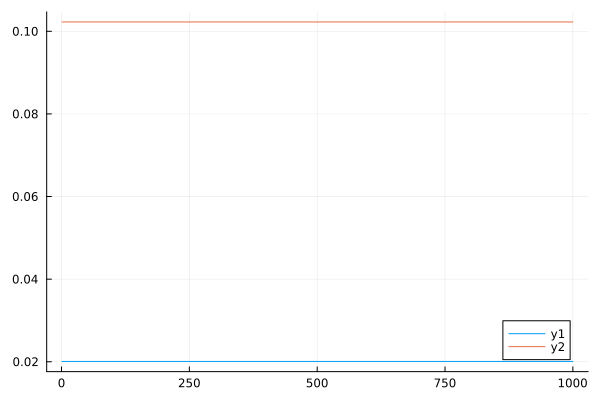

In [10]:
plot(bwd_sol[1:N, 4])
plot!(bwd_sol[N+1:2*N, 4])

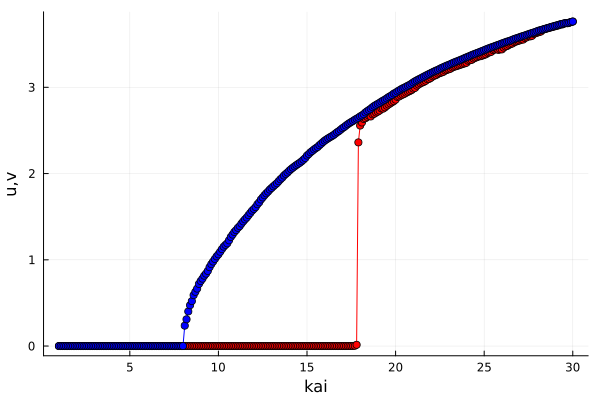

In [11]:
p=plot(kai,amp_fwd,label="", c="red")
scatter!(kai,amp_fwd,label="", c="red")

plot!(kai,amp_bwd,label="", c="blue")
scatter!(kai,amp_bwd,label="", c="blue")


xlabel!("kai")   
ylabel!("u,v") 

##title!("Plot Title")      


savefig(p,"figure_1.png")  # Saves as a PNG file
display(p)

In [12]:
# Open a file to save the results
open("amplitude_variation_sf_6.dat", "w") do io
    # Write the header
    #println(io, "# kai  amp_fwd  amp_bwd")
    
    # Loop over all kai values and write the corresponding amplitude deviations
    for l in 1:length(kai)
        println(io, "$(kai[l])  $(amp_fwd[l])  $(amp_bwd[l])")
    end
end

#println("Data saved to amplitude_variation.dat")


In [19]:
# Define node indices (1 to N)
node_index = 1:N

# Extract cooperator and defector data from solution
x_data = sol[1:N, end]          # Last time step data for cooperators
y_data = sol[N+1:2*N, end]      # Last time step data for defectors

# Combine into a single matrix for saving
data = hcat(node_index, x_data, y_data)

# Save to a .dat file with space-separated values
writedlm("datasf.dat", data, ' ')


LoadError: UndefVarError: `sol` not defined

In [ ]:
#plot(sol[1:N,end-100:end]',label="")
#plot(sol[N+1:2*N,end-100:end]',label="")

In [ ]:
u = ones(5)


In [ ]:
ue=0.5

In [ ]:
sum((u[1:5] .- ue).^2)